In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import seaborn as sns
import shap

from cdc_ml.config import POLLS_PROCESSED,CUSTOMER_CLASS_PROCESSED,PREFERENCE_PROCESSED,BOOKING_MODEL,BEST_PARAMS,OOF,OOF_ADD
from cdc_ml.plots import booking_rate_plot,bootstrap_distribution,plot_calibration_by_volume,bootstrapped_gain_curve,plot_additive_heatmap,concentration_share
from cdc_ml.modeling.data import make_holdout_split
from cdc_ml.features.build_features import build_features,get_whale_users
from cdc_ml.datasets.preference.schema import CleanedPreference
from cdc_ml.modeling.evaluation import cramers_v,compare_feature_sets,paired_t,baseline_pr_auc,pr_auc_ci_by_user,adversarial_validation,per_customer_at_budget,gains_bootstrap
from cdc_ml.modeling.config import CHOSEN_FEATURES



c:\Users\zhiju\Desktop\cdc_ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-08 21:21:01.682 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


## Orientation

This notebook documents the key modeling decisions behind the **booking model** — a model that, given a set of time and preference features, outputs the probability of securing a successful slot (any slot falling within a customer's stated preferences).

For a high-level overview of how the system works end to end, see the README.

The notebook is organized as follows:
1. **Domain & validity** — the data-generating process and what the data can and can't support
2. **Evaluation design** — split strategy, assumptions, and metrics
3. **Features** — the feature set and the decision-driving ones
4. **Baseline** — the performance floor
5. **Feature ablation** — attributing lift to feature groups
6. **Hyperparameter tuning** — the search, and how its result feeds back into evaluation
7. **Final evaluation** — held-out metrics, calibration
8. **Interpretation** — what the model learned (SHAP)
9. **Limitations & business impact** — caveats and the downstream polling decision


## Domain & validity

Each customer's data is assembled from two sources:
- the **polling cycle** — how long a customer has been polling and the cycles they polled in;
- the **preference window** — every day-and-timeslot combination they specified for that cycle.

Slots become available when *other learners cancel*. The bot polls each customer every few minutes at randomized intervals, but per-poll timestamps aren't logged — the data resolves only to the hour. The polling records are therefore aggregated to **hourly granularity**: each row is a (customer, polling-hour), and that hour is the finest time resolution the model sees. Within-hour timing (9:05 vs 9:55) is not distinguishable, which is why `polling_hour` and `polling_dow` — not a finer timestamp — are the time features the model reasons over.
`0	ajithak  2025-08-19 09:00:00+08:00`
`1	ajithak	 2025-08-19 10:00:00+08:00`

**A note on selection bias** The dataset carries two known bias that should frame how every downstream number is read.

**The first bias: customer base are not represented equally.** Almost every polling cycle collected ends in at least one successful booking. Conditioning on "≥1 booking" is selection on a positive outcome, and it biases the sample optimistically: the cycles and preference windows I retain skew toward easier-to-grab time ranges and under-represent genuinely hard slots.

Crucially, this bias is **not uniform across customer types**. One-team customers can take slots from any team and book far more easily; common-pool customers draw from a single shared pool and book far less often. Filtering on "≥1 booking" therefore barely touches the one-team group (most of them book anyway) but heavily filters the common-pool group — only the luckier / better-configured common-pool customers survive. The common-pool customers in this dataset are thus an unrepresentatively successful subset of all common-pool customers, which compresses the true difficulty gap between the two groups and inflates apparent common-pool performance.

The consequence: the final metrics are **not** an unbiased read on the full booking population and should not be treated as a calibrated prediction of real-world booking rates. They characterize the model's behavior on this collected sample.

**The second bias: polling is preference-conditioned.** The bot only ever polls within each customer's stated preference window. So while exposure is uniform across clock time, the *set of slots* observed is determined by self-selected preferences — not a uniform draw over all possible slots. Two consequences follow. First, the data only covers preferred (day, timeslot) regions, so any out-of-preference prediction is extrapolation; in practice this matches deployment — the system only ever scores preference-conditioned polls — so it constrains scope rather than hurting the operational metric. Second, and compounding the success filter above: because preferences are self-chosen *and* the sample is conditioned on ≥1 booking, the preference configurations present skew toward *winnable* ones — customers whose preferences never produced a booking are absent. The preference-derived features, and the metrics built on them, are therefore learned on an optimistically biased preference distribution, reinforcing that the numbers are not a population-representative read.

Within each retained cycle the data is otherwise complete: both failed and successful polls are recorded, and polling runs 24/7, so there are **no structural zeros** — a booking can occur at any polling hour.

Every cleaned or derived dataframe passes **pandera validation** before use. Checks include (non-exhaustively): datetime formatting; date-range sanity to catch human/parsing errors (e.g. a 2025 date mis-entered as 2055); the constraint that a polling timestamp always precedes the cycle's last preference date/time; non-null guarantees on required columns; binary columns containing only {0, 1}; and range checks flagging impossible values (e.g. a negative preference-day count like −5).

The data is real-world; customer identifiers are anonymized (replaced with nicknames). Sample sizes are small — the test set especially — so where it aids illustration I pair the out-of-fold (OOF) set alongside the test set.


In [3]:
df = pd.read_parquet(POLLS_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)
df_pref = pd.read_parquet(PREFERENCE_PROCESSED)

#### Example of pandera validating the dataset

In [4]:
# this schema ensures timestamp integrity and also pref_start is always earlier than pref_end
CleanedPreference.validate(df_pref)

,id,username,day_of_week,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
0,0,ajithak,1,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-19 23:00:00+08:00,0,0,0,0,0,1,1
1,0,ajithak,2,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-20 23:00:00+08:00,0,0,0,0,0,1,1
2,0,ajithak,3,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-21 23:00:00+08:00,0,0,0,0,0,1,1
3,0,ajithak,4,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-22 23:00:00+08:00,0,0,0,0,0,1,1
4,0,ajithak,5,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-23 23:00:00+08:00,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2529,121,addity,2,2025-10-16 00:00:00+08:00,2025-12-14 23:00:00+08:00,2025-12-10 23:00:00+08:00,0,0,0,0,0,1,1
2530,121,addity,3,2025-10-16 00:00:00+08:00,2025-12-14 23:00:00+08:00,2025-12-11 23:00:00+08:00,0,0,0,0,0,1,1
2531,121,addity,4,2025-10-16 00:00:00+08:00,2025-12-14 23:00:00+08:00,2025-12-12 23:00:00+08:00,0,0,0,0,0,1,1
2532,121,addity,5,2025-10-16 00:00:00+08:00,2025-12-14 23:00:00+08:00,2025-12-13 23:00:00+08:00,1,1,1,1,1,1,1


In [5]:
print(f"Total unique customers {df["username"].nunique()}")

Total unique customers 37


In [6]:
print("polling records")
df.head()

polling records


,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,polling_month,polling_day,polling_dow,polling_hour,hours_into_cycle
0,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 09:00:00+08:00,False,8,19,1,9,8,19,1,9,-0.25
1,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 10:00:00+08:00,False,8,19,1,9,8,19,1,10,0.75
2,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 11:00:00+08:00,False,8,19,1,9,8,19,1,11,1.75
3,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 12:00:00+08:00,False,8,19,1,9,8,19,1,12,2.75
4,0,ajithak,2025-08-19 09:15:00+08:00,2025-08-21 11:00:00+08:00,2025-08-19 13:00:00+08:00,False,8,19,1,9,8,19,1,13,3.75


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29612 entries, 0 to 29611
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype                         
---  ------             --------------  -----                         
 0   id                 29612 non-null  int64                         
 1   username           29612 non-null  str                           
 2   cycle_start        29612 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end          29612 non-null  datetime64[us, Asia/Singapore]
 4   polling_at         29612 non-null  datetime64[us, Asia/Singapore]
 5   has_booking        29612 non-null  bool                          
 6   cycle_start_month  29612 non-null  int32                         
 7   cycle_start_day    29612 non-null  int32                         
 8   cycle_start_dow    29612 non-null  int32                         
 9   cycle_start_hour   29612 non-null  int32                         
 10  polling_month      29612 non-null  int32     

In [8]:
print("customer class")
df_class.tail()

customer class


,username,class_type,is_one_team
58,ranjith,3,0
59,fir,3a,0
60,afellow,3a,0
61,isyaf,3a,0
62,max,3a,1


In [9]:
print("preference windows")
df_pref.head()

preference windows


,id,username,day_of_week,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
0,0,ajithak,1,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-19 23:00:00+08:00,0,0,0,0,0,1,1
1,0,ajithak,2,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-20 23:00:00+08:00,0,0,0,0,0,1,1
2,0,ajithak,3,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-21 23:00:00+08:00,0,0,0,0,0,1,1
3,0,ajithak,4,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-22 23:00:00+08:00,0,0,0,0,0,1,1
4,0,ajithak,5,2025-08-19 00:00:00+08:00,2025-08-31 23:00:00+08:00,2025-08-23 23:00:00+08:00,0,0,0,0,0,1,1


Evaluation design
1. Assumptions
The dataset spans 2025-08 to 2026-04 (nine months). Over a window this short, I model booking demand as approximately cyclical and stationary: the same intra-week pattern — e.g. a Tuesday-9am poll — recurs week to week rather than drifting along an absolute calendar axis.
A temporal train/test split exists to guard against distribution drift between past and future. Under the stationarity assumption there is no such drift to guard against, so I deliberately do not split on time. Instead the model is asked to learn recurring cyclical regularities — what a Tuesday-9am poll looks like in general — rather than where a poll sits on an absolute timeline. Given cyclical time features plus preference features, each poll is therefore treated as exchangeable, and no temporal ordering is modeled.
This is a stated assumption, not one nine months of data can fully verify. The window is long enough to observe weekly cyclicality repeating, but not long enough to confirm longer-horizon (e.g. yearly) seasonality. I flag this as a limitation: any annual effect is outside what the current data can support.

2. Split strategy
The primary objective is generalization to new customers (cold-start). All polls from a single customer share near-identical preference and polling-time data, so a random row-level split would leak — the model would be scored on a customer it has effectively already seen. To prevent this, train/test and every cross-validation fold are split by username, keeping each customer wholly within one fold. (username is the grouping key only; it is never a model feature.)
The label is severely imbalanced (~1.3% positive), so I use StratifiedGroupKFold: it preserves group separation (no customer spans folds) while holding the positive rate roughly constant across folds. Out-of-fold (OOF) predictions are pooled across folds for calibration and for the top-k / gains analysis; per-fold scalar metrics are kept only to gauge variance.
The dataset's size and whale-dominance impose a real limitation on how that variance can be estimated. With a handful of whales accounting for most of the volume, there is effectively only one non-degenerate way to partition customers into balanced folds — re-seeding the split does not produce meaningfully different folds, so repeated-seed cross-validation cannot be used to characterize fold-to-fold variance in the usual way.
To recover an honest uncertainty estimate despite this, I report customer-level bootstrap confidence intervals — resampling the customer population rather than rows. This propagates the dominant source of variance (which customers land in evaluation) into the reported metrics and keeps the bootstrap consistent with the group structure used everywhere else. Throughout the ablation that follows, fold-to-fold σ is shown only for context — it is inflated by the small number of non-degenerate folds — so feature decisions are made on cross-validated point estimates together with per-segment lift, with the bootstrap CIs as the final significance check, not on fold σ.

3. Metrics
Bookings are rare (~1.3% base rate), which dictates the metric hierarchy.
PR-AUC (primary). Under severe class imbalance, ROC-AUC is inflated by the large pool of true negatives and can look strong even when minority-class performance is poor. PR-AUC measures behavior directly on the rare positive (booking) class, so it is the faithful summary of what the model is for.
Brier score (secondary, calibration). At this positive rate the Brier score is dominated by easy negatives, so its absolute value is small and uninformative on its own. I use it only as a relative check on predicted probabilities — most usefully before vs after calibration — never as a headline number.
Recall-vs-polls gains curve (operational). Because the model exists to cut polling load, I report the gains curve directly: how much polling can be dropped while retaining most bookings. This is the metric that maps onto the downstream decision, so it is the one an operator would actually read. (The results section reports roughly a 45% polling cut at ~90% booking retention — an offline, counterfactual estimate; the small test panel means this figure carries wide uncertainty.)

4. Heavy-tailed (whale) users
Usage is heavy-tailed: 8 whale customers account for ~50% of all polling, and 5 account for ~50% of all bookings. A single pooled metric is therefore dominated by a few customers and can hide how the model treats the long tail.
To keep comparisons fair, every evaluation is reported split by segment — whales vs non-whales — as well as pooled. The two segments behave differently, and a whale's "lift" is essentially one customer's curve (a near-zero-width interval, not a population estimate), so a feature decision is only accepted if it holds up on the segment that matters, not just on the pooled number. This is why the ablation tables deeper into the chapter carry whale_pr_lift and non_whale_pr_lift alongside pooled PR-AUC: a change that improves the pool while quietly degrading non-whale lift is not an improvement.

In [10]:
df = build_features(df,df_pref,df_class)

#### The train test is splitted using Stratified Group k , with 5 folds 

In [11]:
df_train , df_test = make_holdout_split(df)

Train share -> 0.7927191679049034
Test share -> 0.2072808320950966
Baseline positive rate -> 0.013170336350128327
Train positive rate -> 0.013759904575274772
Test positive rate -> 0.010915607689801238


In [12]:
print(f"train unique users: {df_train["username"].nunique()}")
print( f"test unique users: {df_test["username"].nunique()}")

train unique users: 30
test unique users: 7


In [13]:
has_booking_counts = df["has_booking"].value_counts()
has_booking_share = df["has_booking"].value_counts(normalize=True)

has_booking_stats = pd.concat([has_booking_counts, has_booking_share], axis=1)
has_booking_stats.columns = ["count", "share"]

has_booking_stats

,count,share
has_booking,,
False,29222,0.98683
True,390,0.01317


A density distribution of the polling share among users

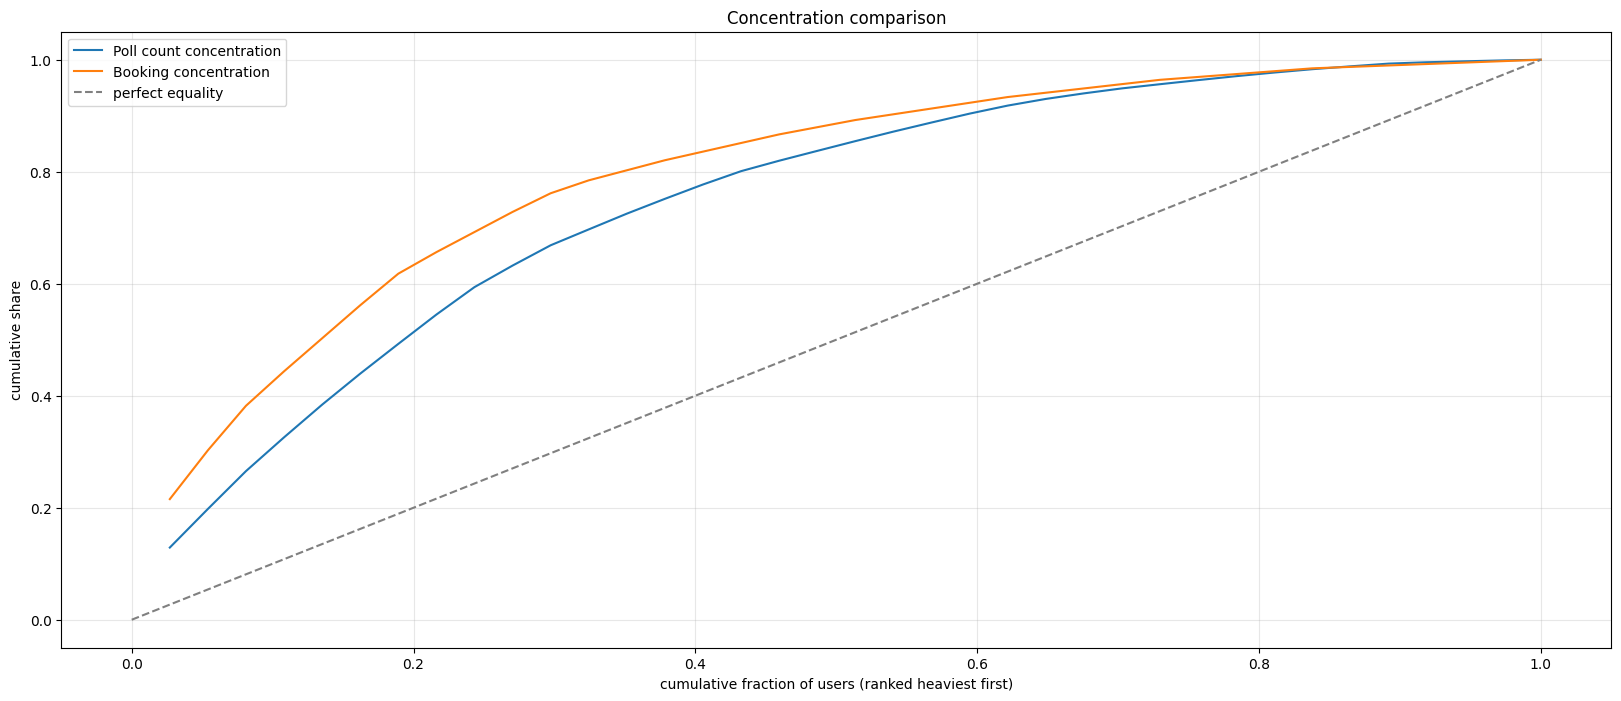

In [14]:
fig = concentration_share(df)

## Features

The feature set is built as a funnel: start with a pool of candidates across four families, then narrow to a final set by asking three questions of every candidate — is it **available at inference time**, does it **duplicate** another feature, and does it **carry real signal**?

### The initial pool

| Family | Candidates |
|---|---|
| **Cycle** | `cycle_start_month`, `cycle_start_day`, `cycle_start_dow`, `cycle_start_hour`, `hours_into_cycle` |
| **Polling** | `polling_month`, `polling_day`, `polling_dow`, `polling_hour` |
| **Preference** | `pref_coverage`, `pref_valid`, `pref_unique_day`, `pref_unique_timeslot`, `pref_dow_count_0…6` |
| **Customer-type** | `class_type`, `is_one_team` |

### *Kept features*

#### Polling features

`polling_hour` carries the strongest signal, and the domain mechanism explains why: a slot frees up only when another learner cancels, so the time of day a slot appears is the natural primary signal. The SHAP analysis (later chapter) confirms it — `polling_hour` dominates the attribution ahead of every other input.

`polling_dow` is kept as a main effect because there is a real weekend penalty: booking rates drop on weekends. This raises a natural follow-up — do `polling_hour` and `polling_dow` interact? Does Tuesday 6pm behave differently from Saturday 6pm? If so, a joint (dow × hour) lookup table would beat a simple additive one. The baseline section tests exactly this.

#### Preference features

These encode the shape of the preference window, derived from domain priors:

- **`pref_coverage`** — number of unique (day, timeslot) combinations requested. E.g. {Tue 9am, Wed 9am, Thu 9am} = 3, out of a possible 49.
- **`pref_valid`** — number of valid preference days still remaining as of the poll. Polling on 2026-01-25 with a preference range of 2026-02-02 → 02-05 gives 4 valid days; a range of 2026-01-23 → 01-26 gives 2 (the earlier days have already passed). For sparse, non-contiguous dates it is simply the count of dates still in the future.
- **`pref_unique_day` / `pref_unique_timeslot`** — number of distinct days and distinct timeslots in the request.
- **`pref_dow_count_0…6`** — one column per weekday holding that weekday's timeslot count. E.g. Tuesday with 3 slots → `pref_dow_count_1 = 3`.

Two properties make these safe to use:

- **No refit, no leakage.** Every preference feature is a per-customer constant derived from the cycle configuration — nothing is fit from data, so there is nothing to refit inside a fold and no path to leakage.
- **Leakage-safe in time.** Preferences are declared at cycle start and the poll time is known at inference, so every value is available before the outcome.

Together they capture the rough shape of a preference window — its breadth, its remaining runway, and its spread across days and times.

#### Customer-type features

`class_type` and `is_one_team` encode the one-team vs common-pool distinction — the difficulty driver identified in the bias analysis.

### *Dropped Features*

#### All cycle features

Every `cycle_*` feature is dropped, for three reasons:

- **Not available at inference.** Some, like `cycle_end`, exist only for analysis and for constructing the polling-hour dataframe; they are not known when a live poll is scored.
- **Redundant with polling counterparts.** `cycle_start_day` / `cycle_start_month` / `cycle_start_hour` are strongly associated with their `polling_*` counterparts (Cramér's V), so they duplicate information the polling features already carry.
- **Confounded by a backlog artifact.** When a cycle's exact start time is unknown it is backlogged to 00:00, which contaminates `cycle_start_hour` and the correlated `hours_into_cycle`; both are dropped on those grounds.

`polling_day`

Largely redundant with `polling_dow` (Cramér's V), and its wide confidence band indicates the day-of-month axis is mostly noise.

`polling_month`

With only nine months of data, it is dominated by which customers were active that month rather than any stable seasonal effect. And since the data does not cover all twelve months, a model given `polling_month` would be forced to extrapolate to months it never saw.

#### Final candidate set

`polling_dow`, `polling_hour`, `pref_coverage`, `pref_valid`, `pref_unique_timeslot`, `pref_unique_day`, `pref_dow_count_0…6`, `class_type`, `is_one_team`

#### Time related features

The boxplot and swarm plot over the spread of the polling count for cycle and polling features , polling_hour and polling_dow are normal compared to cycle with huge variance ?

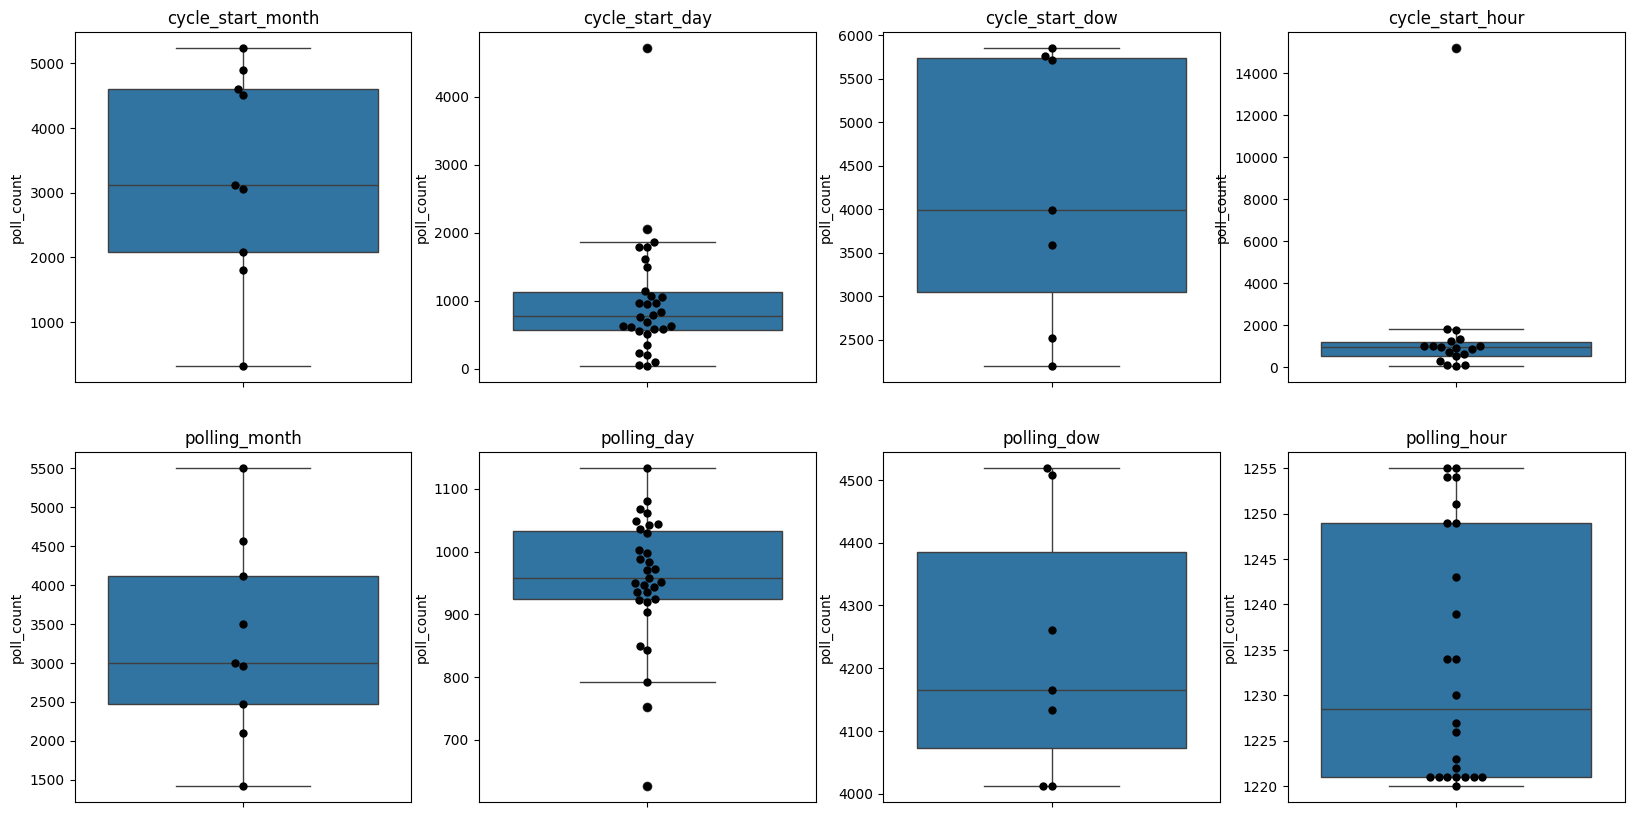

In [15]:
fig,axes = plt.subplots(2,4,figsize=(20,10))

plot_lists = [["cycle_start_month","cycle_start_day","cycle_start_dow","cycle_start_hour",],
              ["polling_month","polling_day","polling_dow","polling_hour"]
              ]

for i in range(2):
    for j in range(4):
        current = plot_lists[i][j]
        count = df.groupby(current)["username"].count().reset_index(name="poll_count")
        sns.boxplot(y=count["poll_count"],ax=axes[i][j])
        sns.swarmplot(y=count["poll_count"], color="black", size=6,ax=axes[i][j])
        axes[i][j].set_title(current)  

Cramers v test shows cycle_* related features largely correlates with polling_* features

In [16]:
v,p=cramers_v(df,"cycle_start_month","polling_month")
print(v,p)
v,p=cramers_v(df,"cycle_start_day","polling_day")
print(v,p)


χ²=145350.9  p=0.00e+00  V=0.783  (df=8)  → large
0.7833034250128832 0.0
χ²=31936.4  p=0.00e+00  V=0.193  (df=29)  → large
0.19284562880375147 0.0


Polling_hour and Polling_dow showing the most promising signals

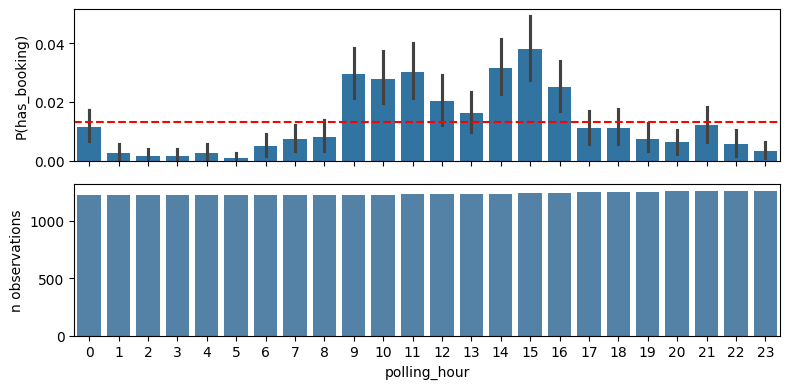

In [17]:
booking_rate_plot(df,"polling_hour")

`polling_dow` is kept as a main effect for a real weekend penalty. One question we are interested in is if polling_hour and polling_dow interacts with each other , for example , a period on tues 6pm might look different on sat 6pm , if there is interactions then a joint lut between the two would provide us with a better estimation than a simple additive one 

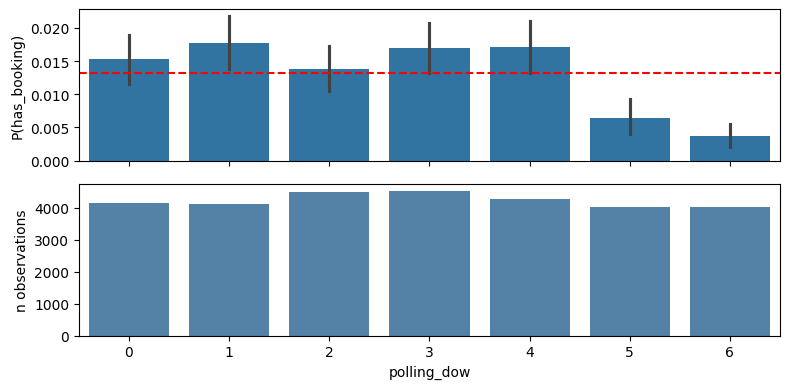

In [18]:
booking_rate_plot(df,"polling_dow")

polling_day is dropped because it is largely correlated with polling_dow with a cramer v test and also the high band of ci just means theres alot of noise within the data 

In [19]:
cramers_v(df,"polling_day","polling_dow")

χ²=11637.7  p=0.00e+00  V=0.256  (df=6)  → large


(np.float64(0.2559318470836812), np.float64(0.0))

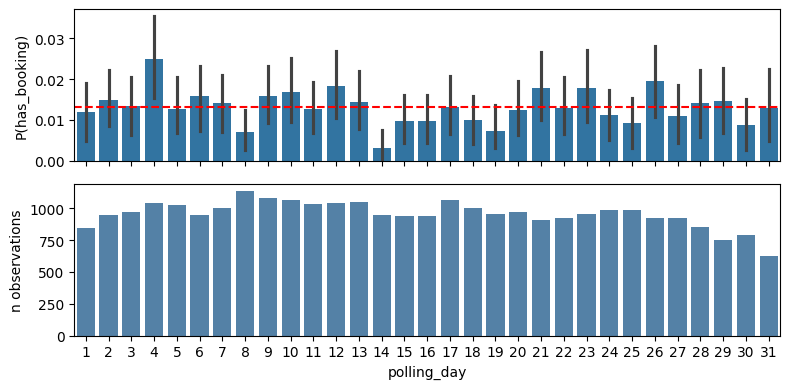

In [20]:
booking_rate_plot(df,"polling_day")

polling month is largely noise due to the small dataset , its results varies depending on which user were active that month , and also because i do not have the complete 12 month of data , even if i pass it to model, the model would also have to extrapolate on the month it never see.


## Baseline

The baselines establish an honest floor on the time signal before any preference or customer features are added, so the later lift is measured against a real predictor rather than against the ~1.3% base rate. All baselines use time features only (`polling_dow`, `polling_hour`).

The design also answers a structural question: **is the DOW/hour signal additive, or is there a genuine DOW × hour interaction?**

To test this I build two lookup tables:

* **Additive LUT** — assumes weekday and hour effects add independently.
* **Joint LUT** — models the full DOW × hour cell.

Every LUT is smoothed toward a prior:

* Marginal/additive cells → base-rate logit.
* Joint cells → their additive prediction.

At a ~1.3% base rate, most cells are thin and unsmoothed estimates would be dominated by sampling noise.

Alongside the LUTs I include two tree models as cross-family checks:

* **Random Forest** finds interactions automatically, so RF ≈ additive is independent confirmation that nothing is left on the table.
* **XGBoost** is the carry-forward model—the standard strong learner on tabular data. If it also tracks the additive LUT on time features, that confirms model complexity is not the lever here; features are.

| Baseline                 | Assumes                    | Role                    |
| ------------------------ | -------------------------- | ----------------------- |
| Constant base rate       | Base rate everywhere       | Absolute floor          |
| `marg_dow` / `marg_hour` | One axis, smoothed         | Single-feature floors   |
| Additive LUT             | DOW + hour, no interaction | Candidate floor         |
| Joint LUT                | Full DOW × hour cells      | Can capture interaction |
| Random Forest / XGBoost  | Flexible time-only models  | Cross-family check      |

#### RF and XGB on time features

**Bottom line:** on time features alone, every model collapses onto the additive LUT.

RF and XGB—both able to represent interactions—do not beat it. Time features take PR-AUC to roughly **2.1× the base rate**, which is the ceiling for timing information.

The floor is therefore set by the additive LUT; any further lift has to come from **features**, not from a more flexible model.

In [21]:
baseline_pr_auc()

,pr_auc,pr_auc_lift,pr_auc_std,whale_lift,non_whale_lift
model,,,,,
add,0.029619,2.152563,0.013156,2.646444,1.993079
const,0.011377,0.826840,0.005123,0.959717,0.985921
joint,0.026846,1.951047,0.011018,2.331795,1.838067
marg_dow,0.014241,1.034947,0.006884,1.074694,1.202607
marg_hour,0.025729,1.869848,0.010831,2.455259,1.618822
rf,0.028318,2.058032,NaN,2.549546,1.916556
xgb,0.029475,2.142060,0.013288,2.656756,1.960292


#### No DOW × hour interaction

The additive LUT and the joint LUT are statistically indistinguishable on PR-AUC.

* Additive LUT lead: **+0.0028**
* Fold-to-fold standard deviation: **0.013**

The observed gap is roughly five times smaller than the natural fold variability, so it cannot be distinguished from zero.

That tie is the result.

The joint LUT is the only baseline flexible enough to exploit a DOW × hour interaction. If such an interaction carried signal, the joint LUT would pull ahead. It does not.

Therefore:

> There is no meaningful DOW × hour interaction to model.

The additive LUT is the baseline to beat.

Later SHAP analysis reaches the same conclusion: no interaction structure appears between the two timing features.

a visualization on the additive lut table heatmap

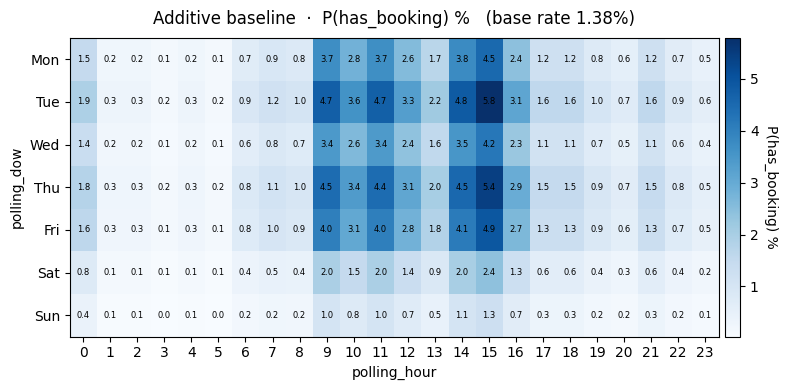

In [22]:
fig,_,_=plot_additive_heatmap(df_train[CHOSEN_FEATURES],df_train["has_booking"])

## Feature ablation & selection

### How selection has to work on this dataset

This dataset is small and positive-sparse: a ~1.3% booking rate spread across a handful of customer-groups. That constraint decides what feature selection can and can't lean on.

The thing it rules out is treating the significance of an individual cross-validation delta as evidence. With so few positives and so few groups, reseeding the splits mostly reshuffles a single heavy user between folds. So there is no honest confidence interval on a single feature's PR-AUC change, and no numeric cutoff ("anything above 0.0X is real") that I can defend. The point estimates are noisy enough that a +0.004 change and a +0.0001 change are the same non-finding, not two different ones.

Selection therefore rests on three things that survive the sample size:

1. **Redundancy**, read from the correlation / VIF structure of the design matrix. This is estimable from every row, so positive sparsity never touches it.
2. **Parsimony.** In a sparse regime every feature is a variance liability, so the burden of proof sits on *inclusion*. A feature is kept only if its removal clearly hurts; "shows no benefit" is sufficient grounds to drop, without having to prove the feature is harmful.
3. **Effect size**, used only where a change is large enough to be unambiguous. I do not adjudicate small deltas by magnitude — I treat them as undecidable and let redundancy and parsimony break the tie.

The PR-AUC numbers below show direction and relative size. They are not significance claims.

### Two ablations

**Leave-one-out (LOO)** — drop one feature, measure the change in pooled PR-AUC. This estimates a feature's marginal contribution *given everything else*. Its blind spot is collinearity: when two features carry overlapping signal, dropping either one alone barely moves the metric because the other covers for it, so LOO systematically under-credits correlated features.

**Group ablation** — drop a whole correlated block at once. This is the fix for that blind spot. If a block is collectively important but individually redundant, only group ablation reveals it.

(Segment lift on heavy vs. light users is tracked alongside both, purely as a guardrail that a pooled change isn't hiding a tail regression. With one heavy user in the test set it is a sanity check, not part of the keep/drop logic.)

Initial candidate set:

```
polling_hour
polling_dow
pref_coverage
pref_unique_timeslot
pref_unique_day
pref_valid
pref_dow          # 7 weekday columns, treated as one feature
class_type
is_one_team
```

### Stage 1 — drop `pref_dow`

`pref_dow` is seven sparse weekday columns. Removing all of them leaves pooled PR-AUC unchanged within the fold spread. There is no detectable signal to keep, and seven columns is real model complexity in a sparse-positive setting — exactly the case parsimony exists for. Dropped.

→ 8 features.

### Stage 2 — prune the redundant preference cluster

This is where LOO is least trustworthy, and where the reasoning matters most.

The four preference features — `pref_coverage`, `pref_unique_day`, `pref_unique_timeslot`, `pref_valid` — are not four independent signals. They are four summaries of the same underlying object: each customer's preference configuration. And they are strongly correlated, with pairwise correlations as high as ~0.67–0.69.

That is precisely the situation where LOO breaks down. Drop any one of them and its neighbors cover the gap, so its individual delta comes out small. Reading those small deltas literally — treating a feature whose removal slightly *helped* the metric as "harmful," and one whose removal slightly *hurt* as "useful" — would be reading noise. None of the four individual deltas is separable from zero on this data, so I do not rank them and I do not interpret their signs. They are one collective non-finding.

The drop rests on the two levers that *are* reliable here:

- **Redundancy.** The correlation structure shows three of the four are largely re-expressions of what the others — and `pref_unique_timeslot` in particular — already encode. Keeping all four means carrying near-duplicate columns into a model that can't afford the extra degrees of freedom.
- **Group ablation.** Removing `pref_coverage`, `pref_unique_day`, and `pref_valid` *together* leaves pooled PR-AUC flat. This is the load-bearing inference: if those three were each contributing independent signal, dropping all three at once would visibly hurt. It doesn't. The redundancy that LOO hid one feature at a time shows up plainly at the block level.

So the whole trio goes, and only `pref_unique_timeslot` is kept from the preference block — not because its individual LOO drop here is large (it isn't yet), but because it is the least redundant of the four, and because Stage 3 shows what it is actually worth once its correlated cover is removed.

→ 5 features.

### Stage 3 — confirm the 5-feature set

With the redundant cluster gone, the picture changes completely. Now *every* remaining feature, removed on its own, causes a large drop in PR-AUC — roughly 38% to 54%. These are an order of magnitude beyond the small fluctuations seen in Stages 1–2.

This is where effect size does the work. I can't put error bars on these drops, but a change ten times the size of the earlier noise-level wobbles is robust to whatever that noise is. Nothing here is indifferent; all five features are load-bearing. The keep line is drawn across that large gap — not at a threshold inside the noise.

The most instructive case is `pref_unique_timeslot` itself. On the 8-feature set its removal barely moved the metric; on the clean 5-feature set it is the *largest* single drop. Nothing about the feature changed — only its context did. Once the correlated preference variables that were masking it are removed, its true contribution is exposed. That frame-dependence is the entire reason group ablation runs alongside LOO: a feature's apparent importance depends on which of its neighbors are present.

### The two views, reconciled

LOO and group ablation answer different questions, and reading them together prevents the wrong conclusion:

- Removing the preference block as a whole costs ~42% of PR-AUC, but the individual preference LOO drops sum to only ~24%. The missing ~18 points is shared signal that redundancy hid from LOO. As a group, the preference features are the single biggest contributor — even though no individual one dominates.
- Removing the class features (`class_type` + `is_one_team`) together costs ~39%, *less* than the sum of their individual drops (~47%) — so those two partly overlap with each other as well.

Three statements that are all true, because they answer different questions:

- Most important *individual* feature on the candidate set: `class_type`.
- Most important *group*: the preference features.
- Most important *individual* feature on the final set: `pref_unique_timeslot`.

### Final feature set

```
polling_hour
polling_dow
pref_unique_timeslot
class_type
is_one_team
```

Two timing features, one preference-shape feature, two customer-type features. It is the minimal set that survives both ablations: every retained feature causes a large, unambiguous drop when removed, and every dropped feature was cut either for no detectable signal (`pref_dow`) or for redundancy within a correlated block (the preference trio).

One honest caveat. At this sample size it is possible that a dropped feature carries a sliver of unique signal too small to detect. The cost of discarding that sliver is negligible; the cost of carrying redundant columns in a sparse-positive model — overfitting, unstable calibration, more surface to maintain — is not. That asymmetry is a deliberate engineering choice, not a claim that five features is provably optimal.


In [23]:

df[["pref_unique_day","pref_coverage","pref_unique_timeslot","pref_valid"]].corr("pearson")

,pref_unique_day,pref_coverage,pref_unique_timeslot,pref_valid
pref_unique_day,1.000000,0.671662,0.354991,0.669423
pref_coverage,0.671662,1.000000,0.689822,0.426549
pref_unique_timeslot,0.354991,0.689822,1.000000,0.315486
pref_valid,0.669423,0.426549,0.315486,1.000000


In [24]:
test_type = "step1"
target = "full_wo_pref_dow"
compare_feature_sets(target_run=test_type+"_"+target)

,feature_id,pr_auc_pooled,diff_vs_full,pr_auc_folds_std,pct_diff_vs_full,whale_pr_lift,whale_lift_vs_full,non_whale_pr_lift,non_whale_lift_vs_full
20,wo_pref_dow,0.074494,0.001658,0.045741,2.276356,4.066976,0.002433,2.136054,0.082217
13,full,0.072836,0.000000,0.047553,0.000000,4.064543,0.000000,2.053837,0.000000


In [25]:
test_type = "step2"
target = "full_loo"
compare_feature_sets(target_run=test_type+"_"+target)

,feature_id,pr_auc_pooled,diff_vs_full,pr_auc_folds_std,pct_diff_vs_full,whale_pr_lift,whale_lift_vs_full,non_whale_pr_lift,non_whale_lift_vs_full
34,wo_pref_coverage,0.078452,0.003957,0.048667,5.312225,4.271086,0.204110,2.161344,0.025291
76,wo_valid_unique_coverage,0.077690,0.003196,0.043908,4.289964,4.071875,0.004899,2.621254,0.485200
48,wo_pref_unique_day,0.074539,0.000045,0.047970,0.060684,4.089420,0.022445,2.017649,-0.118404
27,full,0.074494,0.000000,0.045741,0.000000,4.066976,0.000000,2.136054,0.000000
41,wo_pref_valid,0.069277,-0.005218,0.042962,-7.004025,3.790651,-0.276325,2.293468,0.157415
55,wo_pref_unique_timeslot,0.060761,-0.013733,0.047708,-18.435631,3.901291,-0.165685,1.735391,-0.400663
69,wo_is_one_team,0.059543,-0.014951,0.040993,-20.070461,3.713565,-0.353411,1.855467,-0.280586
62,wo_class_type,0.038133,-0.036361,0.034529,-48.811027,2.927569,-1.139407,1.712737,-0.423316


In [26]:
test_type = "step3"
target = "core_loo"
compare_feature_sets(target_run=test_type+"_"+target)

,feature_id,pr_auc_pooled,diff_vs_full,pr_auc_folds_std,pct_diff_vs_full,whale_pr_lift,whale_lift_vs_full,non_whale_pr_lift,non_whale_lift_vs_full
83,full,0.077690,0.000000,0.043908,0.000000,4.071875,0.000000,2.621254,0.000000
97,wo_class_type,0.047841,-0.029849,0.031826,-38.420885,2.890679,-1.181196,2.047012,-0.574242
104,wo_is_one_team,0.044363,-0.033327,0.036763,-42.896995,3.599358,-0.472517,2.183676,-0.437578
90,wo_pref_unique_timeslot,0.035549,-0.042141,0.024533,-54.242088,3.829327,-0.242548,1.952784,-0.668470


Hyperparameter tuning
The search is built to mirror the evaluation protocol rather than optimize against an easier objective:

RandomizedSearchCV, n_iter=50 — XGBoost's space is high-dimensional and mostly continuous, so a grid would spend budget on axes the model is insensitive to. Random sampling covers the joint space far more efficiently at a fixed budget, and 50 draws is enough to locate a strong region given the dataset size.
StratifiedGroupKFold, group=username — the same splitter used for final evaluation. Grouping by customer keeps every user entirely on one side of each split, so hyperparameters are selected for cold-start (unseen-customer) generalization, not for memorizing customers seen in training. Stratifying on has_booking matters at a ~1.4% base rate: it prevents folds from landing with too few (or zero) positives, which would make average precision unstable.
scoring="average_precision" — PR-AUC is the project's primary metric under this imbalance. ROC-AUC would be dominated by the abundant negatives and overstate quality; average precision tracks the positive (booking) class, which is what the system exists to catch. Tuning and reporting on the same metric avoids picking a model that wins on a proxy and loses on what matters.
refit=False — the search exists only to choose hyperparameters. The production artifact is fit by train.py with the full calibration + OOF pipeline, so we want the winning params, not a quietly-refit estimator that skipped that pipeline (it also saves the final refit's compute). With refit=False only best_score_ and best_params_ are exposed — exactly what we hand downstream.
Persisting best_params_ to JSON — decouples selection from training. train.py reads the file, so the notebook is never the source of truth for the model and the pipeline reruns reproducibly from disk.

In [27]:
with open(BEST_PARAMS, "r") as f:
    best_params = json.load(f)
    print(best_params)

{'subsample': 0.9, 'reg_lambda': 20, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 1.0, 'colsample_bytree': 0.8}


### Final evaluation 

The headline metric is the out-of-fold (OOF) PR-AUC under StratifiedGroupKFold, which estimates cold-start performance on customers never seen in training. Across all 30 customers the model scores PR-AUC = 0.075, a 5.4× lift over the 1.4% base rate (95% customer-level bootstrap CI [1.8×, 8.0×]).
The held-out test set scores lower — 2.6× (CI [1.5×, 4.8×]) — but this is not evidence of overfitting, for three reasons:

The intervals overlap. Test's CI [1.5×, 4.8×] and OOF's [1.8×, 8.0×] share most of their range, and the test point estimate falls inside the OOF interval. The central estimates differ, but at this sample size the gap is not separable from sampling variation.
The test sample is tiny and positive-sparse — 7 customers, 67 positives, a 1.1% base rate. PR-AUC is high-variance in this regime, which shows in the width of the non-whale CI and, most starkly, in the whale segment: a single customer (22 positives at a 0.6% rate, zero-width CI). Per-segment test numbers, whales especially, are not interpretable and are not reported as headline figures.
The two customer pools genuinely differ. Adversarial validation separates train from test rows at AUC 0.70 — moderate on the usual scale. The held-out customers are a small, somewhat-different draw, which is exactly what "small sample" looks like when n is counted in customers rather than rows.

One caveat on the adversarial figure: the preference features are per-user constants, so with only 7 distinct held-out customers the adversarial classifier can partly identify them by their fixed feature signatures rather than by broad covariate drift. 0.70 therefore likely overstates the true population shift — but it sits well above 0.5, so a real difference is present.
Bottom line: the OOF estimate is the reported result because it aggregates over all 30 customers and is the stable read on cold-start generalization. The test set is a directional sanity check; its lower PR-AUC is consistent with a small, mildly shifted customer draw plus noise, not with a failure to generalize.

In [28]:
model = joblib.load(BOOKING_MODEL)
oof_add = np.load(OOF_ADD)

In [29]:
whales_pc,_ = get_whale_users()
whales_pt_mask_train = df_train["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_train = ~df_train["username"].isin(whales_pc).to_numpy()

whales_pt_mask_test = df_test["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_test = ~df_test["username"].isin(whales_pc).to_numpy()

Model Score: OOF
ALL
users=30 rows=23474 positives=323 base=0.0138
PR-AUC=0.0746 (5.42x)  95% CI=[0.0252, 0.1094] ([1.83x, 7.95x])



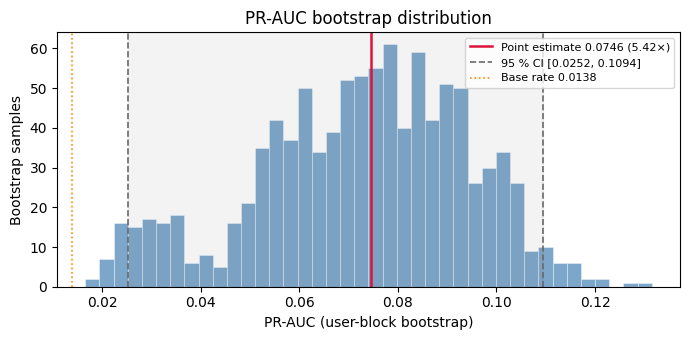

WHALES
users=7 rows=12320 positives=173 base=0.0140
PR-AUC=0.0871 (6.20x)  95% CI=[0.0139, 0.1224] ([0.99x, 8.71x])



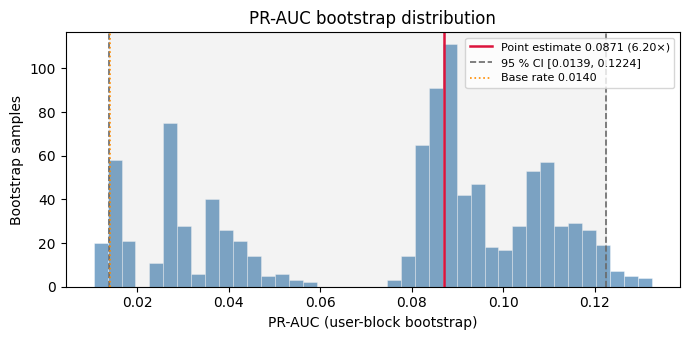

NON-WHALES
users=23 rows=11154 positives=150 base=0.0134
PR-AUC=0.0676 (5.03x)  95% CI=[0.0219, 0.1257] ([1.63x, 9.35x])



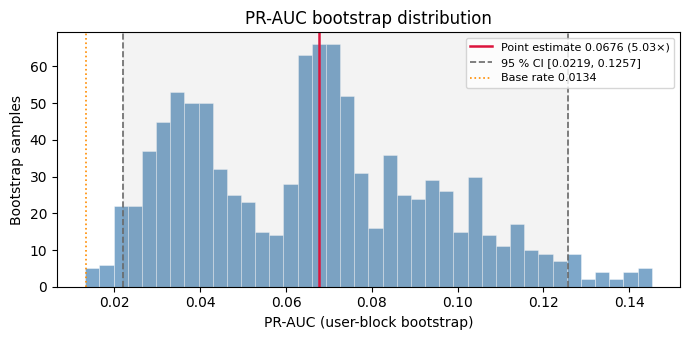

In [30]:
oof_df = pd.read_parquet(OOF)

print("Model Score: OOF")
y_train,p_oof,cal_oof,groups = oof_df["y_true"].to_numpy(),oof_df["p_oof"].to_numpy(),oof_df["cal_oof"].to_numpy(),oof_df["groups"].to_numpy()
whale_users = df_train.loc[whales_pt_mask_train,["username"]]
non_whales_users = df_train.loc[non_whales_pt_mask_train,["username"]]
print("ALL");        
boots,point,base,hi,lo= pr_auc_ci_by_user(y_train, cal_oof, groups)
bootstrap_distribution(boots,point,base,hi,lo)

print("WHALES");     
boots,point,base,hi,lo=pr_auc_ci_by_user(y_train[whales_pt_mask_train],  cal_oof[whales_pt_mask_train],  whale_users)
bootstrap_distribution(boots,point,base,hi,lo)

print("NON-WHALES");
boots,point,base,hi,lo=pr_auc_ci_by_user(y_train[~whales_pt_mask_train], cal_oof[~whales_pt_mask_train], non_whales_users)
bootstrap_distribution(boots,point,base,hi,lo)

Model Score: Test
ALL
users=7 rows=6138 positives=67 base=0.0109
PR-AUC=0.0285 (2.61x)  95% CI=[0.0166, 0.0524] ([1.52x, 4.80x])



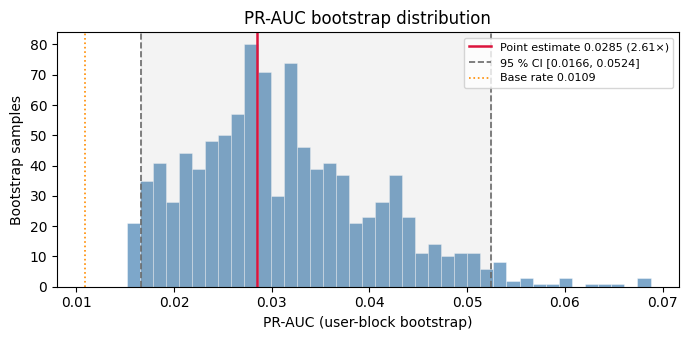

WHALES
users=1 rows=3816 positives=22 base=0.0058
PR-AUC=0.0149 (2.59x)  95% CI=[0.0149, 0.0149] ([2.59x, 2.59x])



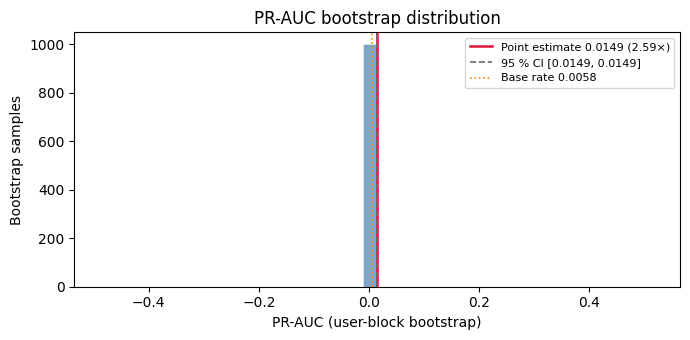

NON-WHALES
users=6 rows=2322 positives=45 base=0.0194
PR-AUC=0.0361 (1.86x)  95% CI=[0.0235, 0.0632] ([1.21x, 3.26x])



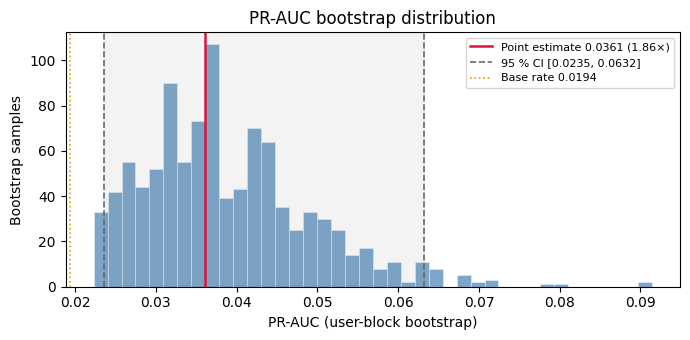

In [31]:
p_cal = model.predict_proba(df_test)
y_test = df_test["has_booking"].to_numpy()


print("Model Score: Test")
whale_users = df_test.loc[whales_pt_mask_test,["username"]]
non_whales_users = df_test.loc[non_whales_pt_mask_test,["username"]]

print("ALL");        
boots,point,base,hi,lo=pr_auc_ci_by_user(y_test, p_cal, df_test["username"])
bootstrap_distribution(boots,point,base,hi,lo)


print("WHALES");     
boots,point,base,hi,lo=pr_auc_ci_by_user(y_test[whales_pt_mask_test],  p_cal[whales_pt_mask_test],  whale_users)
bootstrap_distribution(boots,point,base,hi,lo)

print("NON-WHALES"); 
boots,point,base,hi,lo=pr_auc_ci_by_user(y_test[~whales_pt_mask_test], p_cal[~whales_pt_mask_test], non_whales_users)
bootstrap_distribution(boots,point,base,hi,lo)

In [32]:
clf = adversarial_validation(df_train[CHOSEN_FEATURES], df_test[CHOSEN_FEATURES])

adversarial AUC = 0.702   (0.5 = identical, ~0.65+ = medium, 0.8+ = strong)


Calibrating the out-of-fold predictions with Platt scaling
I calibrate on the pooled out-of-fold (OOF) scores rather than on in-fold predictions. Because every OOF score is produced by a model that never saw that row in training, the pooled set is an unbiased sample of the score distribution the model will actually produce at deployment. Fitting the calibrator here avoids the optimism that comes from calibrating on scores the model has already fit.
For the calibrator I use Platt scaling — a two-parameter logistic fit, P(booking | s) = σ(A·s + B), mapping the raw score s to a probability. The choice over isotonic regression is driven by the data, not by habit. At a ~1.3% base rate the OOF set holds very few positives relative to its size, and isotonic regression — which fits an essentially free monotonic step function — chases that sparse positive signal and overfits the sample; Platt's two parameters are regularized by the parametric form and stay stable when positives are scarce. The distortion also has the right shape for a sigmoid: the calibration-by-volume plot shows both the whale and non-whale curves sitting just below the diagonal in a smooth, monotonic over-prediction, with no kinks or reversals that would justify isotonic's extra flexibility.
One property is worth stating explicitly, because it sets up everything downstream: Platt scaling is a monotonic transform of the score, so it does not change the ranking. PR-AUC, top-k recall, and the gains curve are identical before and after calibration — they are all rank-based. Calibration only moves the probability values, which is what the Brier score and the calibration plot measure, and what lets the business read a prediction as a literal "this poll has a ~6% chance of yielding a booking." So ranking quality and probability quality are cleanly separated: the boosted model does the ranking, Platt makes the numbers honest. The fitted calibrator is bundled into the BookingModel artifact alongside the estimator and the feature list, and applied unchanged to the sealed test set.

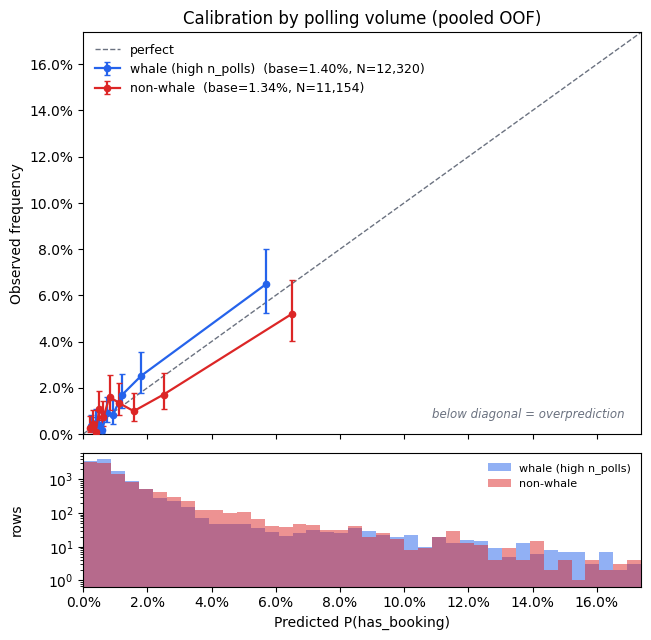

In [33]:
fig = plot_calibration_by_volume(p_oof,y_train,whales_pt_mask_train);

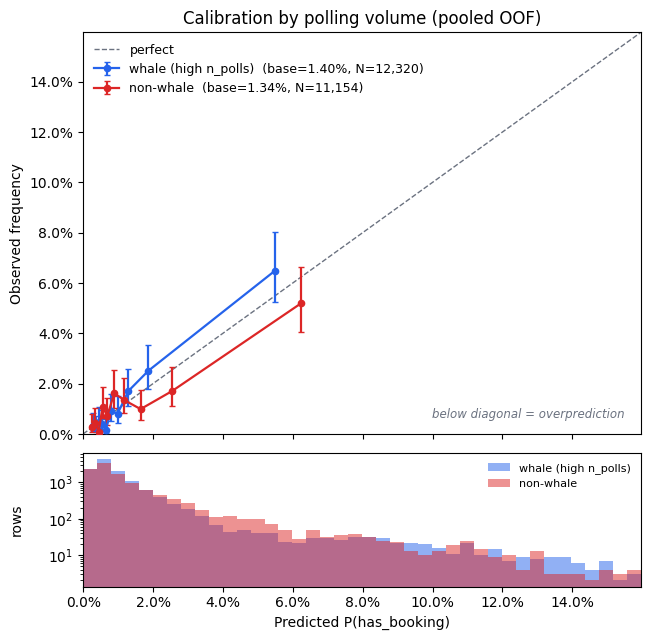

In [34]:
fig = plot_calibration_by_volume(cal_oof,y_train,whales_pt_mask_train);

Per-customer recall at a polling budget
The gains curve is an aggregate — it tells me what fraction of all bookings survive when I keep the top X% of polls by predicted probability. But aggregate recall is dominated by the highest-volume customers, so it can look healthy while quietly starving an individual. The per-customer budget check guards against that. At a fixed 60% polling budget (drop the 40% lowest-probability polls), I compute recall separately for each customer and split on the whale flag, since whales carry most of the volume and the aggregate curve is essentially their curve.
OOF (the decision read):

Booking whales — median recall 93%, worst 57% (n=4)
Everyone else — median recall 100%, worst 0% (n=26)

Test (final confirmation):

Booking whales — median recall 86%, worst 73% (n=2)
Everyone else — median recall 100%, worst 57% (n=5)

The median story is the reassuring one: most non-whale customers keep all of their bookings under a 40% polling cut, and whales keep roughly 85–93%. The worst-case figures — 0% on OOF, 57% on test for the non-whales — land on the lowest-volume customers, where a single booking falling just below the budget threshold zeroes out (or halves) the recall. That is a small-denominator artifact, not a systematic failure mode: with one or two bookings, per-customer recall is a coarse, high-variance statistic.
The point that matters most for a test panel this small (≈7 customers) is that OOF and test agree — same median levels, same shape, worst-cases of the same character. I make the 60%-budget operating decision on OOF and treat the test panel purely as a final confirmation read, which keeps the test set sealed from the decision itself.

 booking whales: median recall 93%, worst 57%  (n=4)
       the rest: median recall 100%, worst 0%  (n=26)


<Axes: xlabel='whale', ylabel='recall'>

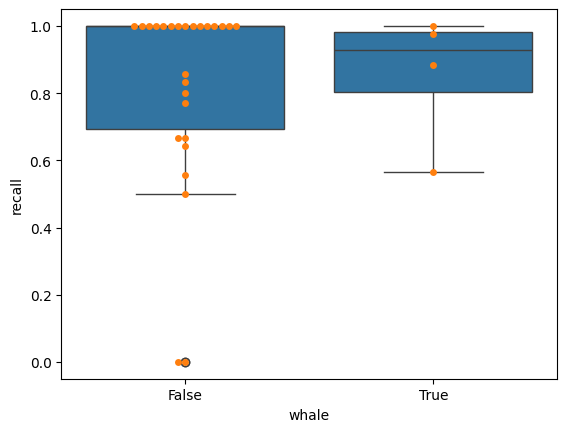

In [35]:
t = per_customer_at_budget(df_train, cal_oof, budget=0.6)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  
sns.swarmplot(data=t,x="whale",y="recall") 

 booking whales: median recall 86%, worst 73%  (n=2)
       the rest: median recall 100%, worst 57%  (n=5)


<Axes: xlabel='whale', ylabel='recall'>

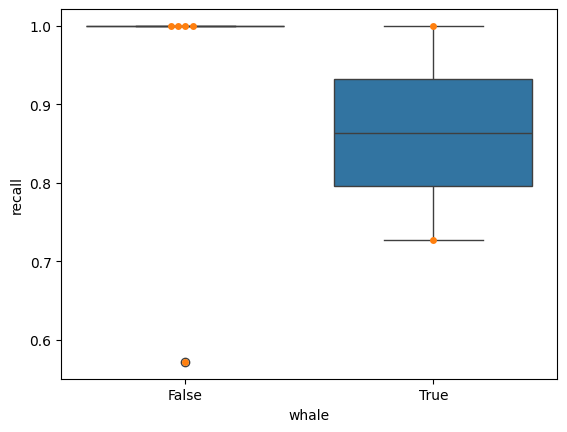

In [36]:
t = per_customer_at_budget(df_test, p_cal, budget=0.6)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  
sns.swarmplot(data=t,x="whale",y="recall")  

XGB
60% of bookings  ->  22.6% of polling
70% of bookings  ->  30.5% of polling
80% of bookings  ->  45.2% of polling
95% of bookings  ->  77.9% of polling

10% of polling  ->  41.5% of bookings
20% of polling  ->  56.7% of bookings
30% of polling  ->  69.0% of bookings
40% of polling  ->  75.8% of bookings

add
60% of bookings  ->  24.4% of polling
70% of bookings  ->  35.3% of polling
80% of bookings  ->  47.9% of polling
95% of bookings  ->  76.6% of polling

10% of polling  ->  27.3% of bookings
20% of polling  ->  52.6% of bookings
30% of polling  ->  66.3% of bookings
40% of polling  ->  74.3% of bookings


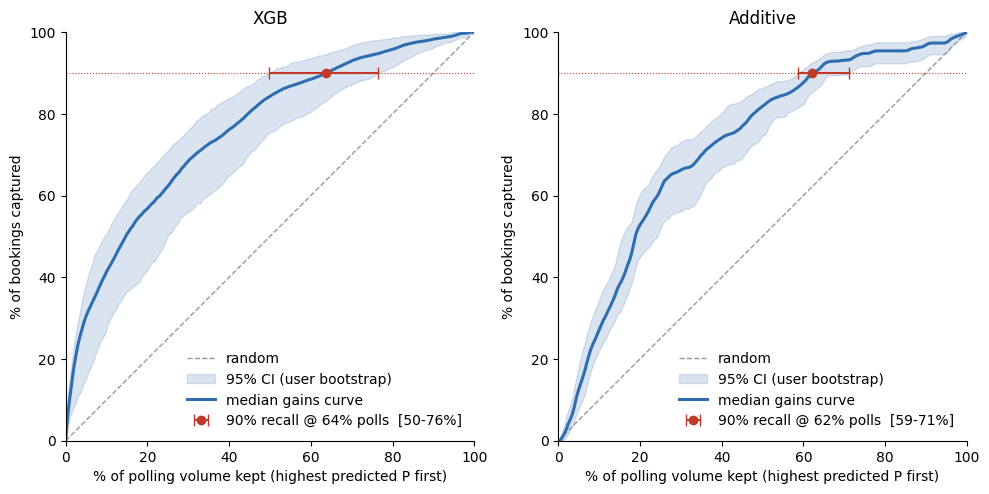

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

res_xgb = gains_bootstrap(df_train, cal_oof)
res_add = gains_bootstrap(df_train, oof_add)

print("XGB")
for target in [0.60, 0.70, 0.80, 0.95]:
    poll_needed = np.interp(target, res_xgb["y"], res_xgb["x"])  
    print(f"{target:.0%} of bookings  ->  {poll_needed:.1%} of polling")

print()
for target in [0.1, 0.2, 0.3, 0.4]:
    recall_at_budget = np.interp(target, res_xgb["x"], res_xgb["y"]) 
    print(f"{target:.0%} of polling  ->  {recall_at_budget:.1%} of bookings")
    

print()
print("add")
for target in [0.60, 0.70, 0.80, 0.95]:
    poll_needed = np.interp(target, res_add["y"], res_add["x"])  
    print(f"{target:.0%} of bookings  ->  {poll_needed:.1%} of polling")

print()
for target in [0.1, 0.2, 0.3, 0.4]:
    recall_at_budget = np.interp(target, res_add["x"], res_add["y"])  
    print(f"{target:.0%} of polling  ->  {recall_at_budget:.1%} of bookings")

bootstrapped_gain_curve(res_xgb,axes[0])
bootstrapped_gain_curve(res_add,axes[1])
axes[0].set_title("XGB")
axes[1].set_title("Additive")

plt.tight_layout()


In [40]:
test = gains_bootstrap(df_train, oof_add)
print("XGB")
for target in [0.60, 0.70, 0.80, 0.95]:
    poll_needed = np.interp(target, test["y"], test["x"])  
    print(f"{target:.0%} of bookings  ->  {poll_needed:.1%} of polling")

print()
for target in [0.1, 0.2, 0.3, 0.4]:
    recall_at_budget = np.interp(target, test["x"], test["y"]) 
    print(f"{target:.0%} of polling  ->  {recall_at_budget:.1%} of bookings")

bootstrapped_gain_curve(res_xgb,axes[0])
bootstrapped_gain_curve(res_add,axes[1])
axes[0].set_title("XGB")
axes[1].set_title("Additive")
    

XGB
60% of bookings  ->  24.4% of polling
70% of bookings  ->  35.3% of polling
80% of bookings  ->  47.9% of polling
95% of bookings  ->  76.6% of polling

10% of polling  ->  27.3% of bookings
20% of polling  ->  52.6% of bookings
30% of polling  ->  66.3% of bookings
40% of polling  ->  74.3% of bookings


Text(0.5, 1.0, 'Additive')

60% of bookings  ->  27.9% of polling
70% of bookings  ->  34.6% of polling
80% of bookings  ->  44.2% of polling
95% of bookings  ->  53.7% of polling

10% of polling  ->  20.4% of bookings
20% of polling  ->  41.8% of bookings
30% of polling  ->  64.0% of bookings
40% of polling  ->  71.6% of bookings
50% of polling  ->  92.5% of bookings
60% of polling  ->  98.5% of bookings


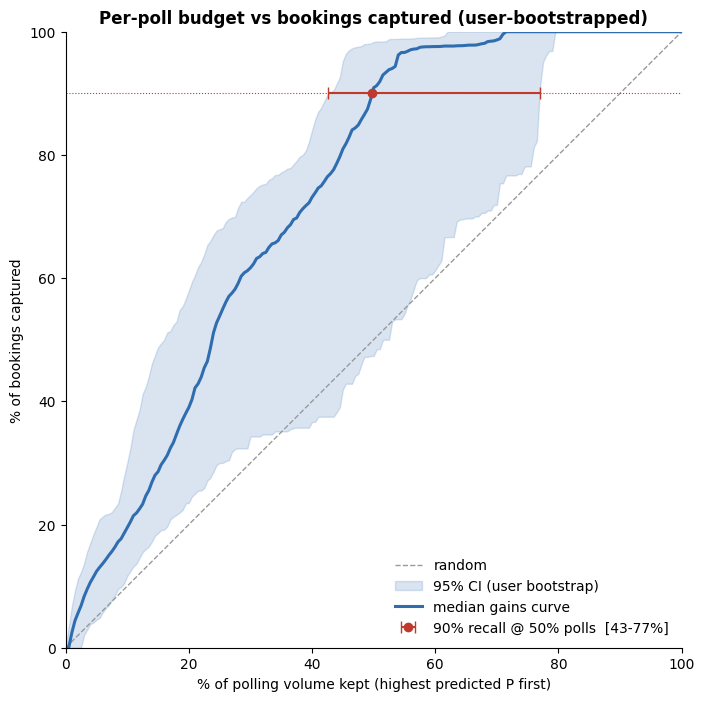

In [ ]:

fig, res = bootstrapped_gain_curve(df_test, p_cal)

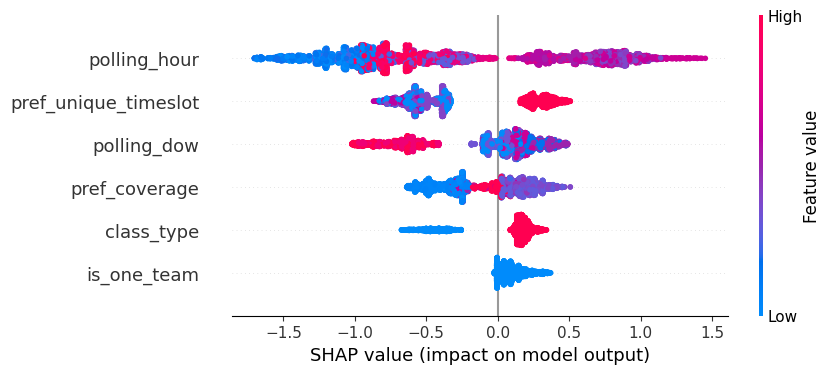

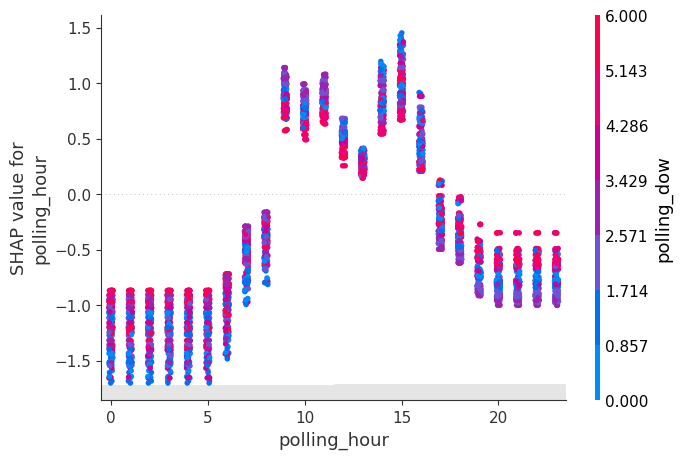

In [ ]:
explainer = shap.TreeExplainer(model.booster)   
sv = explainer(df_test[CHOSEN_FEATURES])                  
shap.plots.beeswarm(sv)
shap.plots.scatter(sv[:, "polling_hour"], color=sv[:, "polling_dow"])

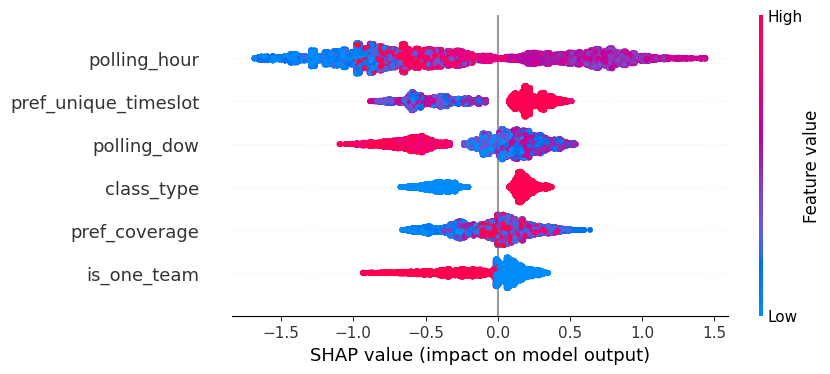

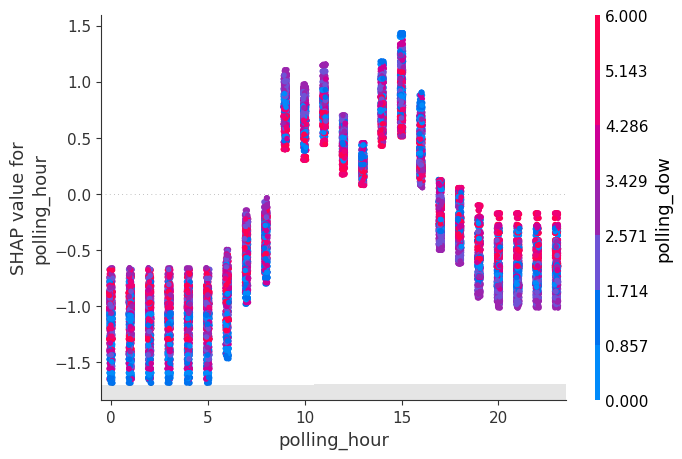

In [ ]:
explainer = shap.TreeExplainer(model.booster)   
sv = explainer(df_train[CHOSEN_FEATURES])                  
shap.plots.beeswarm(sv)
shap.plots.scatter(sv[:, "polling_hour"], color=sv[:, "polling_dow"])